## Example 3c:
Replication of example 3a, but using the flow-matching model instead of the MDN model. As discussed, the MDN model needed the min component allocation to be zeroed out before a calibrated model could be trained. The flow-matching model doesn't have that floor to begin with, though, so let's see if it does any better right out of the box.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import math
from pathlib import Path
import warnings

import numpy as np
import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning
from matplotlib import pyplot

In [3]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [4]:
from cynosure.config_defaults import (
    get_default_training_config,
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
get_default_velocity_config,
)
from cynosure.object_distribution import FixedBead
from cynosure.utilities.training_utils import NoValidationBar, safe_load_from_checkpoint
from cynosure.zstack_decoding import ZstackSolver_FlowMatching
from cynosure.information.calibration import (
    calculate_rank_statistics,
    generate_and_predict,
    get_expected_rank_statistics,
    test_rank_uniformity,
)
from cynosure.zstack_decoding.zstack_solver import _twin_parity_signs

#### Simulation setup

In [5]:
use_pretrained = True  # enable to load weights from one of my checkpoints

train_cfg = get_default_training_config()
sim_cfg = get_default_simulation_config()
opt_cfg = get_default_optical_config()
phase_cfg = get_default_phase_config()
amp_cfg = get_default_amplitude_config()
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config(
    min_photons=10_000,
    max_photons=10_000,
    max_background=0,
)
vel_cfg = get_default_velocity_config()

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)

In [6]:
rng_seed = 123
z_jitter = 1.5  # um
device = "cuda" if torch.cuda.is_available() else "cpu"

#### Fitting a model

In [7]:
_ = pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_FlowMatching(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    vel_cfg=vel_cfg,
    object_distribution=object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=z_jitter,
    noise_cfg=noise_cfg,
    hidden_channels=(32, 64),
    embedding_dims=128,
)
solver = solver.to(device)

Seed set to 123


In [8]:
checkpoint_path = Path("./pretrained_models/example_3c/checkpoints/final.ckpt")
if use_pretrained and checkpoint_path.is_file():
    solver = safe_load_from_checkpoint(checkpoint_path, solver).eval()
else:
    trainer = pl.Trainer(
        max_epochs=400,
        accelerator=device,
        log_every_n_steps=100,
        callbacks=[NoValidationBar()],
        gradient_clip_val=1.0,
    )
    trainer.fit(solver)
    solver = solver.eval()

#### Assess initial calibration

In [9]:
_ = pl.seed_everything(rng_seed+1, workers=True)
solver = solver.to(device)

Seed set to 124


In [10]:
batch_size = 4096
num_samples = 1023
num_bins = 32
chunk_size = 128

In [11]:
coef_blocks, pred_coef_blocks = generate_and_predict(solver, batch_size, num_samples, chunk_size)

In [12]:
ranks = [calculate_rank_statistics(cb, pcb, chunk_size) for (cb, pcb) in zip(coef_blocks, pred_coef_blocks)]
ranks = torch.cat(ranks, dim=-1)
ranks = ranks[:, ~solver.coefficients.is_pinned.cpu()]

In [13]:
uniform_mean, uniform_std = get_expected_rank_statistics(batch_size, num_bins)
pvalues = test_rank_uniformity(ranks, num_bins)

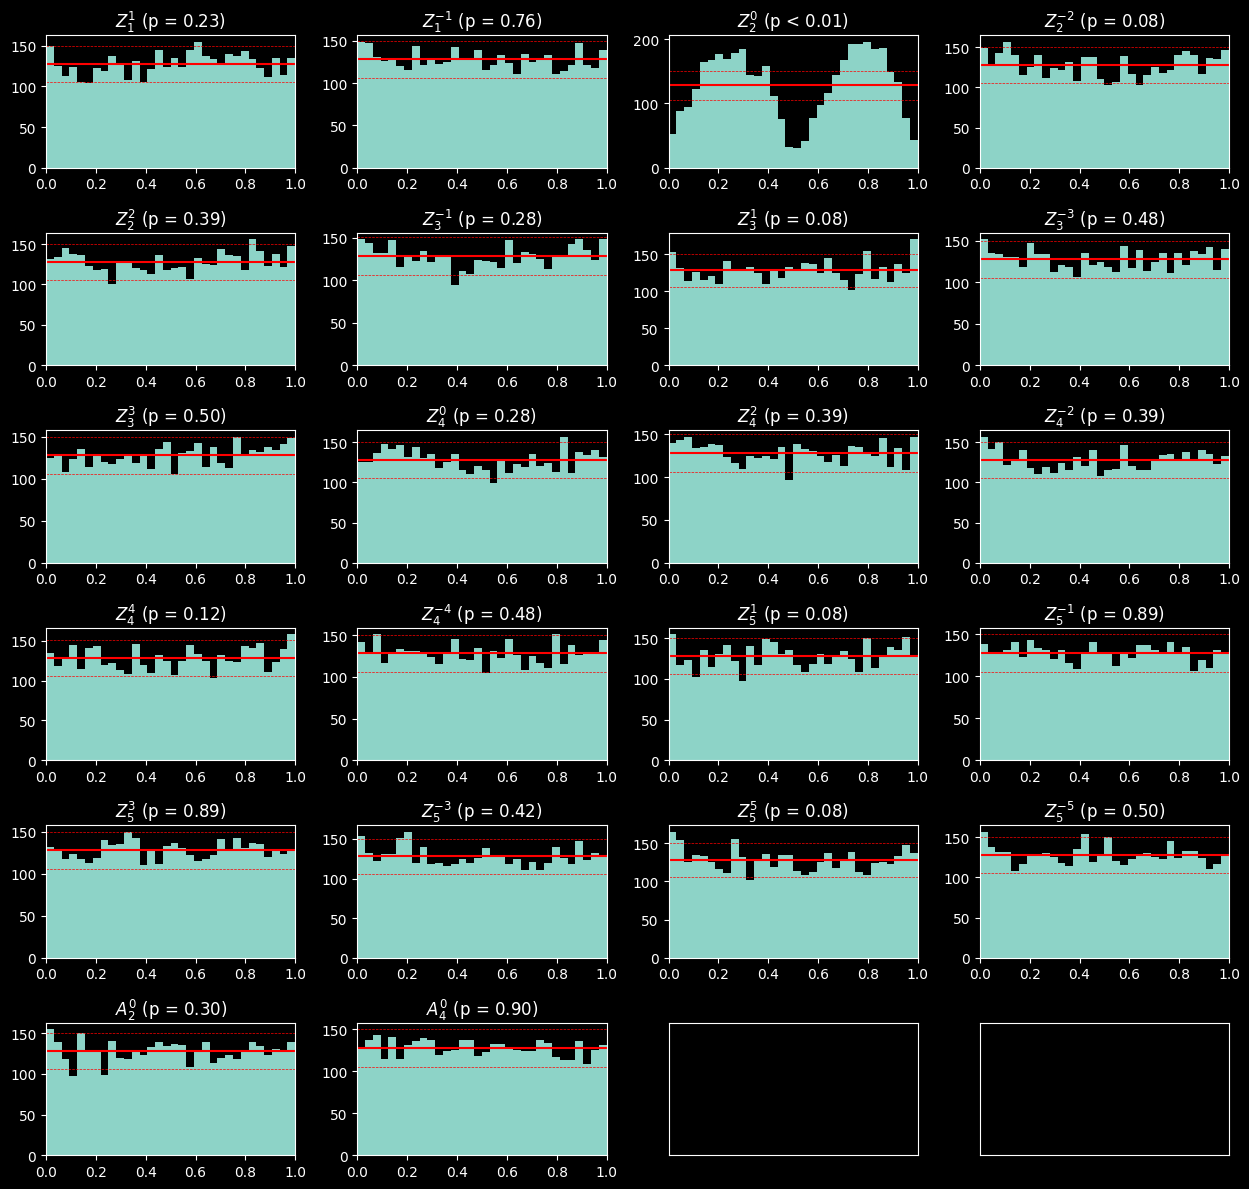

In [14]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7
num_coefs = ranks.shape[-1]

num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)
labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        out = ax.hist(ranks[:, i].numpy(force=True), range=(0, 1), bins=num_bins)
        ax.axhline(uniform_mean, ls="-", color="r")
        ax.axhline(uniform_mean - 2*uniform_std, ls="--", lw=0.5, color="r")
        ax.axhline(uniform_mean + 2*uniform_std, ls="--", lw=0.5, color="r")
        ax.set_ylim(bottom=0)
        ax.set_xlim(0, 1)

        p_lbl = f"p = {pvalues[i]:.2f}" if pvalues[i] > 0.01 else "p < 0.01"
        ax.set_title(f"{solver.coefficients.nonpinned_labels[i]} ({p_lbl})")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

#### Plotting truth vs. predicted

In [15]:
phase_signs = _twin_parity_signs(solver.propagator.phase_projector.nm_indices, negate_even_n=True).cpu()
amp_signs = _twin_parity_signs(solver.propagator.amp_projector.nm_indices, negate_even_n=False).cpu()
signs = torch.cat([phase_signs, amp_signs])
is_even = signs < 0

true_coefs = solver.coefficients.join(*coef_blocks)  # [B, N]
pred_coefs = solver.coefficients.join(*pred_coef_blocks)  # [B, S, N]

is_wrong_sign = (pred_coefs[..., is_even] * true_coefs[:, None, is_even]).sum(-1) < 0  # [B, S]
pred_coefs = torch.where(is_wrong_sign[..., None], pred_coefs * signs, pred_coefs)  # [B, S, N]

true_coefs = true_coefs[:, ~solver.coefficients.is_pinned.cpu()]
pred_coefs = pred_coefs[:, :, ~solver.coefficients.is_pinned.cpu()]

zscores = (pred_coefs.mean(1) - true_coefs) / pred_coefs.std(1)

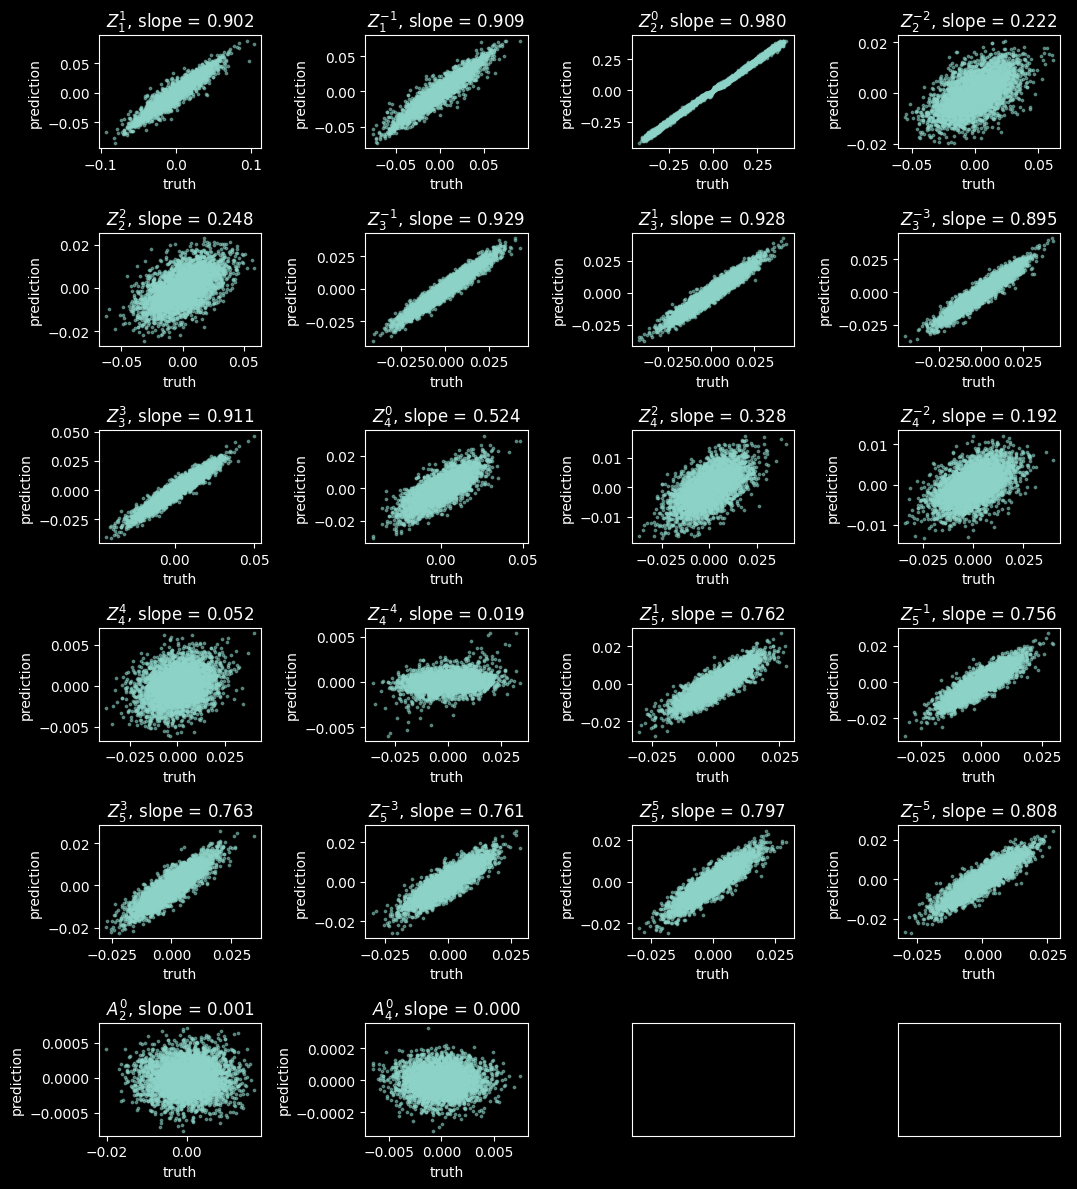

In [16]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.6

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        truth = true_coefs[:, i].numpy(force=True)  # [B,]
        preds = pred_coefs[:, :, i].mean(1).numpy(force=True)  # [B,]
        ax.scatter(truth, preds, s=3, alpha=0.5)

        slope = np.polyfit(truth, preds, deg=1)[0]
        ax.set_title(f"{labels[i]}, slope = {slope:.3f}")
        ax.set_ylabel("prediction")
        ax.set_xlabel("truth")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

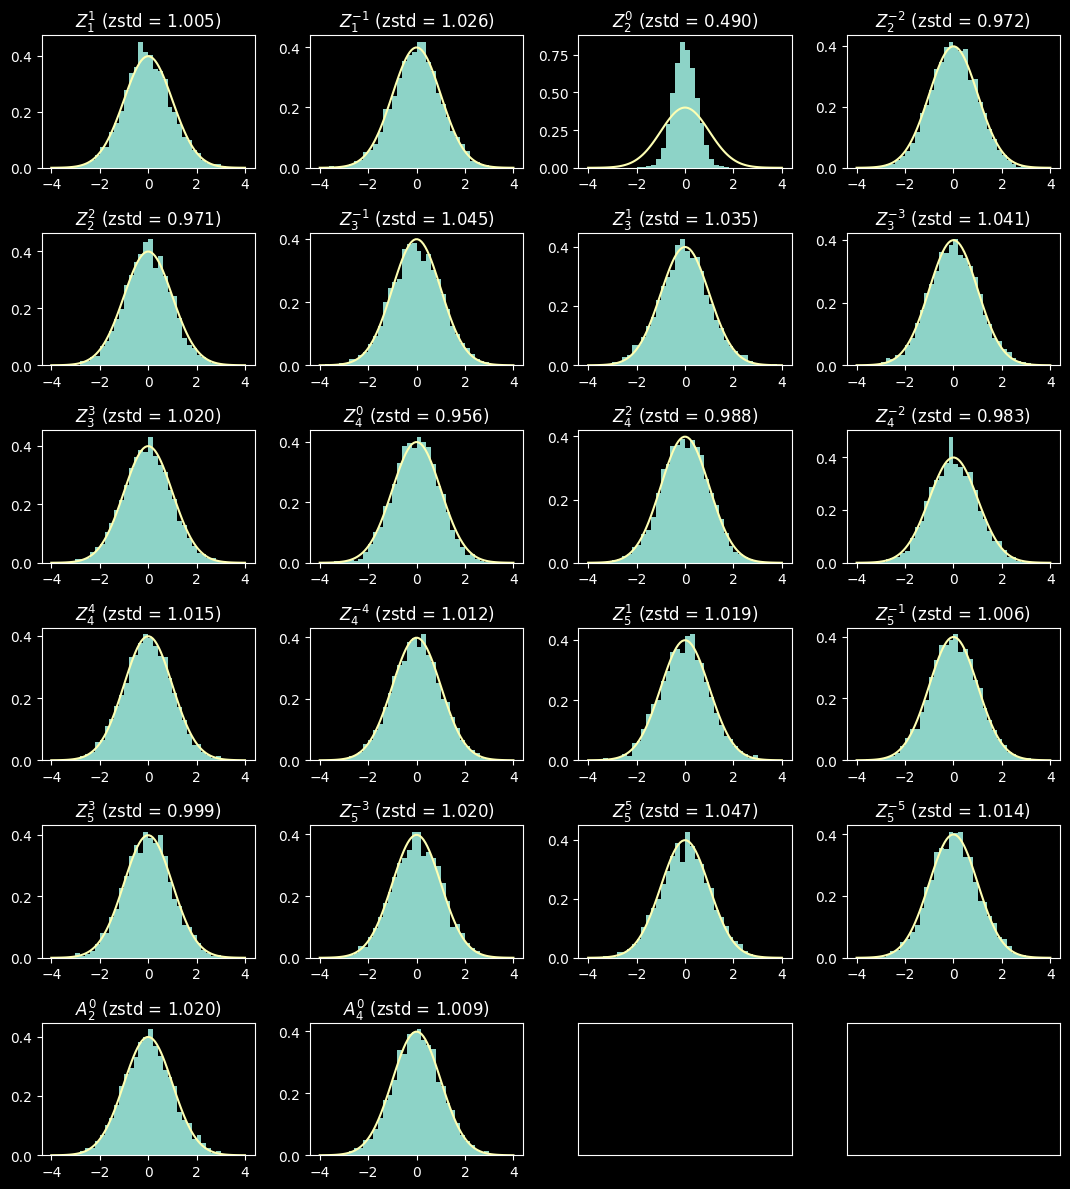

In [17]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.6

num_coefs = solver.coefficients.num_nonpinned_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.coefficients.nonpinned_labels

xmax = 4
x = np.linspace(-xmax, xmax, 100)
standard_normal = (1.0/math.sqrt(2*math.pi)) * np.exp(-0.5*x**2)

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        _ = ax.hist(zscores[..., i].numpy(force=True).ravel(), range=(-xmax, xmax), bins=40, density=True)
        ax.plot(x, standard_normal)
        ax.set_title(f'{solver.coefficients.nonpinned_labels[i]} (zstd = {zscores[..., i].std():.3f})')
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()